In [ ]:
import pandas as pd

data = pd.read_csv("imdb_top_1000.csv")

print(data.info())
print(data.head())

print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Poster_Link    1000 non-null   object 
 1   Series_Title   1000 non-null   object 
 2   Released_Year  1000 non-null   object 
 3   Certificate    899 non-null    object 
 4   Runtime        1000 non-null   object 
 5   Genre          1000 non-null   object 
 6   IMDB_Rating    1000 non-null   float64
 7   Overview       1000 non-null   object 
 8   Meta_score     843 non-null    float64
 9   Director       1000 non-null   object 
 10  Star1          1000 non-null   object 
 11  Star2          1000 non-null   object 
 12  Star3          1000 non-null   object 
 13  Star4          1000 non-null   object 
 14  No_of_Votes    1000 non-null   int64  
 15  Gross          831 non-null    object 
dtypes: float64(2), int64(1), object(13)
memory usage: 125.1+ KB
None
                                

In [ ]:
data['Gross'] = data['Gross'].str.replace(',', '').astype(float)
data['Gross'].fillna(data['Gross'].median(), inplace=True)

data['Runtime'] = data['Runtime'].str.replace(' min', '').astype(int)

data.drop(['Poster_Link', 'Overview'], axis=1, inplace=True)

print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Series_Title   1000 non-null   object 
 1   Released_Year  1000 non-null   object 
 2   Certificate    899 non-null    object 
 3   Runtime        1000 non-null   int64  
 4   Genre          1000 non-null   object 
 5   IMDB_Rating    1000 non-null   float64
 6   Meta_score     843 non-null    float64
 7   Director       1000 non-null   object 
 8   Star1          1000 non-null   object 
 9   Star2          1000 non-null   object 
 10  Star3          1000 non-null   object 
 11  Star4          1000 non-null   object 
 12  No_of_Votes    1000 non-null   int64  
 13  Gross          1000 non-null   float64
dtypes: float64(3), int64(2), object(9)
memory usage: 109.5+ KB
None


<ipython-input-6-593b2d8f1eba>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Gross'].fillna(data['Gross'].median(), inplace=True)


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler

data = pd.read_csv("imdb_top_1000.csv")

print(data['Released_Year'].unique())

data['Released_Year'] = pd.to_numeric(data['Released_Year'], errors='coerce')
data['Released_Year'].fillna(data['Released_Year'].median(), inplace=True)
data['Released_Year'] = data['Released_Year'].astype(int)

data['Released_Decade'] = (data['Released_Year'] // 10) * 10
print(data[['Released_Year', 'Released_Decade']].head())

data['Gross'] = data['Gross'].str.replace(',', '').astype(float)
data['Gross'].fillna(data['Gross'].median(), inplace=True)

data['Runtime'] = data['Runtime'].str.replace(' min', '').astype(int)

data.drop(['Poster_Link', 'Overview'], axis=1, inplace=True)

genre_dummies = data['Genre'].str.get_dummies(sep=', ')
data = pd.concat([data, genre_dummies], axis=1)

data['Certificate'] = data['Certificate'].fillna('Unknown')
data['Certificate'] = data['Certificate'].astype('category').cat.codes

scaler = MinMaxScaler()
data[['Runtime', 'Gross', 'No_of_Votes']] = scaler.fit_transform(data[['Runtime', 'Gross', 'No_of_Votes']])

data['is_popular'] = (data['IMDB_Rating'] > 8).astype(int)

['1994' '1972' '2008' '1974' '1957' '2003' '1993' '2010' '1999' '2001'
 '1966' '2002' '1990' '1980' '1975' '2020' '2019' '2014' '1998' '1997'
 '1995' '1991' '1977' '1962' '1954' '1946' '2011' '2006' '2000' '1988'
 '1985' '1968' '1960' '1942' '1936' '1931' '2018' '2017' '2016' '2012'
 '2009' '2007' '1984' '1981' '1979' '1971' '1963' '1964' '1950' '1940'
 '2013' '2005' '2004' '1992' '1987' '1986' '1983' '1976' '1973' '1965'
 '1959' '1958' '1952' '1948' '1944' '1941' '1927' '1921' '2015' '1996'
 '1989' '1978' '1961' '1955' '1953' '1925' '1924' '1982' '1967' '1951'
 '1949' '1939' '1937' '1934' '1928' '1926' '1920' '1970' '1969' '1956'
 '1947' '1945' '1930' '1938' '1935' '1933' '1932' '1922' '1943' 'PG']
   Released_Year  Released_Decade
0           1994             1990
1           1972             1970
2           2008             2000
3           1974             1970
4           1957             1950


<ipython-input-7-4931fe40272c>:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Released_Year'].fillna(data['Released_Year'].median(), inplace=True)  # 填充缺失值为中位数
<ipython-input-7-4931fe40272c>:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col]

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
import pandas as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

print(data.head())

data = data.drop(['Series_Title', 'Genre'], axis=1)

label_encoder = LabelEncoder()
for col in ['Director', 'Star1', 'Star2', 'Star3', 'Star4']:
    data[col] = label_encoder.fit_transform(data[col].astype(str))

print(data.dtypes)

imputer = IterativeImputer(random_state=42)
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

X = data_imputed.drop(['IMDB_Rating', 'is_popular'], axis=1)
y = data_imputed['IMDB_Rating']

print(X.isnull().sum())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

rf_best = RandomForestRegressor(
    random_state=42,
    n_estimators=grid.best_params_['n_estimators'],
    max_depth=grid.best_params_['max_depth'],
    min_samples_split=grid.best_params_['min_samples_split']
)
rf_best.fit(X_train, y_train)

lr = LinearRegression().fit(X_train, y_train)
xgb = XGBRegressor(random_state=42).fit(X_train, y_train)

print("\nModel evaluation results:")
for model, name in zip([lr, rf_best, xgb], ['Linear Regression', 'Random Forest (Best)', 'XGBoost']):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name} - MSE: {mse:.2f}, MAE: {mae:.2f}")

数据集预览：
               Series_Title  Released_Year  Certificate   Runtime  \
0  The Shawshank Redemption           1994            1  0.351449   
1             The Godfather           1972            1  0.471014   
2           The Dark Knight           2008           14  0.387681   
3    The Godfather: Part II           1974            1  0.568841   
4              12 Angry Men           1957           12  0.184783   

                  Genre  IMDB_Rating  Meta_score              Director  \
0                 Drama          9.3        80.0        Frank Darabont   
1          Crime, Drama          9.2       100.0  Francis Ford Coppola   
2  Action, Crime, Drama          9.0        84.0     Christopher Nolan   
3          Crime, Drama          9.0        90.0  Francis Ford Coppola   
4          Crime, Drama          9.0        96.0          Sidney Lumet   

            Star1           Star2  ... Music Musical  Mystery  Romance  \
0     Tim Robbins  Morgan Freeman  ...     0       0       

Training Linear Regression...
Linear Regression - MSE: 0.04, MAE: 0.16, R²: 0.32, Adjusted R²: 0.18, Training Time: 0.00s
Training Random Forest...
Random Forest - MSE: 0.04, MAE: 0.15, R²: 0.44, Adjusted R²: 0.32, Training Time: 1.09s
Training XGBoost...
XGBoost - MSE: 0.04, MAE: 0.16, R²: 0.34, Adjusted R²: 0.21, Training Time: 0.29s
Training SVR...
SVR - MSE: 0.06, MAE: 0.21, R²: -0.00, Adjusted R²: -0.20, Training Time: 0.05s
Training Gradient Boosting...
Gradient Boosting - MSE: 0.04, MAE: 0.15, R²: 0.42, Adjusted R²: 0.31, Training Time: 0.42s
Training KNN...
KNN - MSE: 0.08, MAE: 0.23, R²: -0.27, Adjusted R²: -0.52, Training Time: 0.00s
Training Decision Tree...
Decision Tree - MSE: 0.07, MAE: 0.20, R²: -0.09, Adjusted R²: -0.30, Training Time: 0.02s
Training LightGBM...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000851 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_c

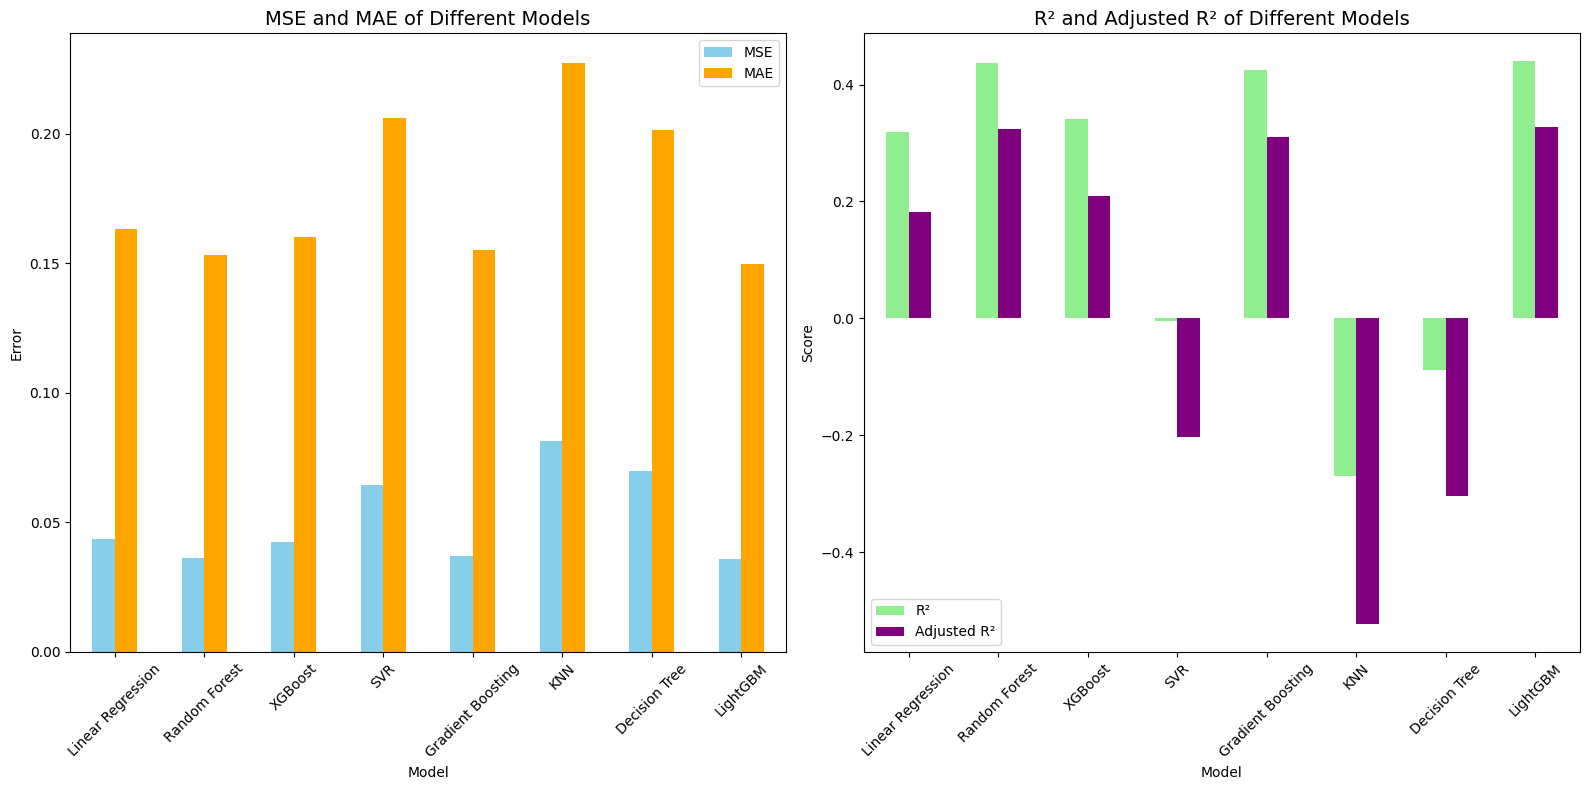

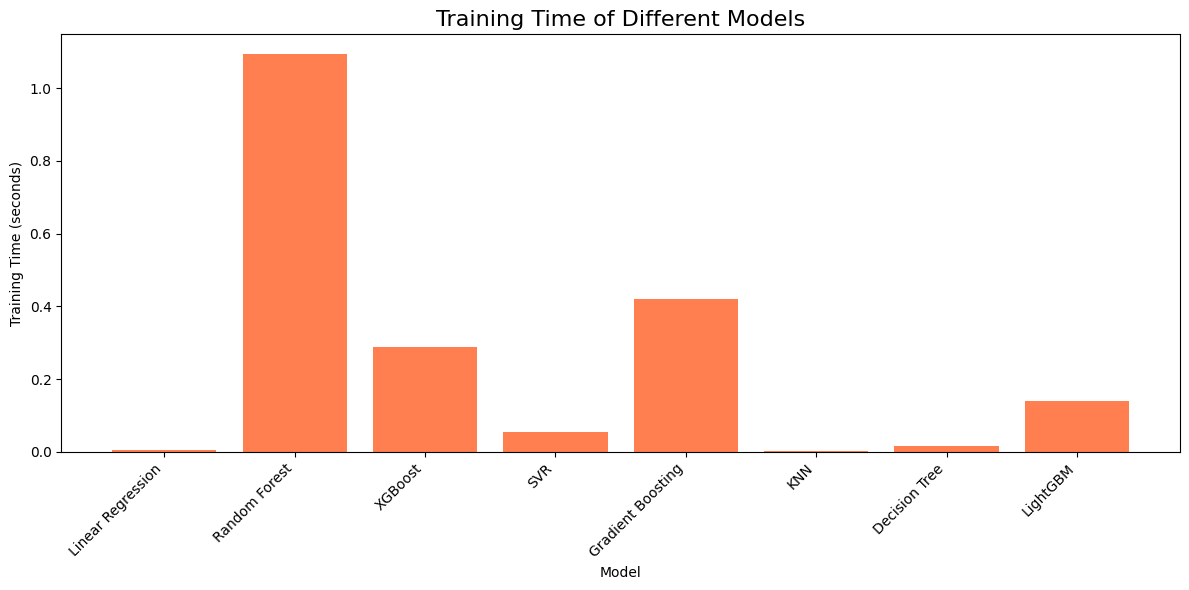

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "SVR": SVR(kernel='rbf'),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42)
}

results = []

def adjusted_r2_score(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

for name, model in models.items():
    print(f"Training {name}...")
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()

    train_time = end_time - start_time
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    adj_r2 = adjusted_r2_score(r2, len(y_test), X_test.shape[1])

    results.append({
        "Model": name,
        "MSE": mse,
        "MAE": mae,
        "R²": r2,
        "Adjusted R²": adj_r2,
        "Training Time (s)": train_time
    })
    print(f"{name} - MSE: {mse:.2f}, MAE: {mae:.2f}, R²: {r2:.2f}, Adjusted R²: {adj_r2:.2f}, Training Time: {train_time:.2f}s")

results_df = pd.DataFrame(results)

best_model = results_df.sort_values("MSE").iloc[0]
print(f"\nBest Model: {best_model['Model']} with MSE: {best_model['MSE']:.2f}")

baseline_model = results_df[results_df["Model"] == "Linear Regression"].iloc[0]
print(f"Baseline Model (Linear Regression) - MSE: {baseline_model['MSE']:.2f}, MAE: {baseline_model['MAE']:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

results_df.set_index("Model")[["MSE", "MAE"]].plot(kind="bar", ax=axes[0], color=["skyblue", "orange"])
axes[0].set_title("MSE and MAE of Different Models", fontsize=14)
axes[0].set_ylabel("Error")
axes[0].set_xlabel("Model")
axes[0].tick_params(axis="x", rotation=45)

results_df.set_index("Model")[["R²", "Adjusted R²"]].plot(kind="bar", ax=axes[1], color=["lightgreen", "purple"])
axes[1].set_title("R² and Adjusted R² of Different Models", fontsize=14)
axes[1].set_ylabel("Score")
axes[1].set_xlabel("Model")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.bar(results_df["Model"], results_df["Training Time (s)"], color="coral")
plt.title("Training Time of Different Models", fontsize=16)
plt.ylabel("Training Time (seconds)")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

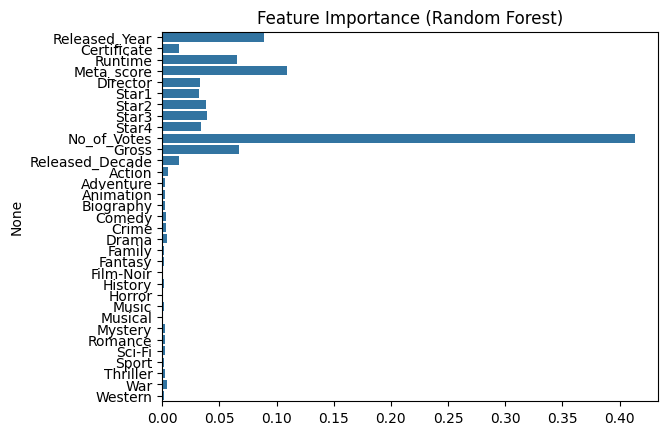

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = rf.feature_importances_
features = X.columns

sns.barplot(x=feature_importances, y=features)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [ ]:
feature_importances = rf.feature_importances_
features = X.columns

actor_columns = ['Star1', 'Star2', 'Star3', 'Star4']
actor_importances = {}

for col in actor_columns:
    importance = feature_importances[list(features).index(col)]
    unique_encoded_values = data[col].unique()
    actor_names = label_encoder.inverse_transform(unique_encoded_values)
    actor_importances.update({actor_name: importance for actor_name in actor_names})

sorted_actor_importances = sorted(actor_importances.items(), key=lambda x: x[1], reverse=True)

print("Most important actors and their feature importances:")
for actor_name, importance in sorted_actor_importances[:4]:
    print(f"{actor_name}: {importance:.4f}")

最重要的四个演员及其特征重要性：
507: 0.0341
284: 0.0341
257: 0.0341
611: 0.0341


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression - Accuracy: 0.66, F1 Score: 0.31
              precision    recall  f1-score   support

           0       0.69      0.89      0.77       132
           1       0.50      0.22      0.31        68

    accuracy                           0.66       200
   macro avg       0.59      0.55      0.54       200
weighted avg       0.62      0.66      0.62       200

Decision Tree - Accuracy: 0.74, F1 Score: 0.59
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       132
           1       0.65      0.54      0.59        68

    accuracy                           0.74       200
   macro avg       0.72      0.70      0.70       200
weighted avg       0.74      0.74      0.74       200

Random Forest - Accuracy: 0.76, F1 Score: 0.51
              precision    recall  f1-score   support

           0       0.75      0.96      0.84       132
           1       0.83      0.37      0.51        68

    accuracy                       

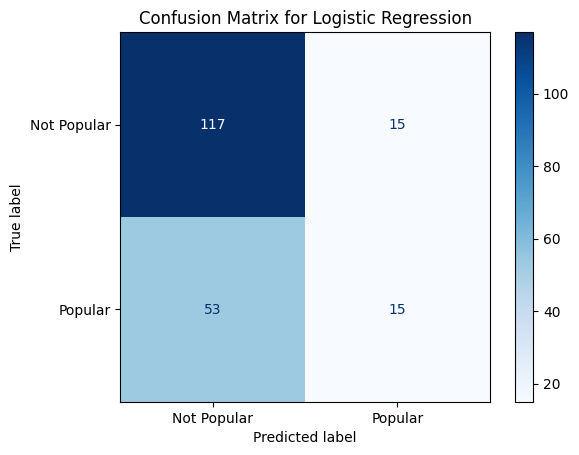

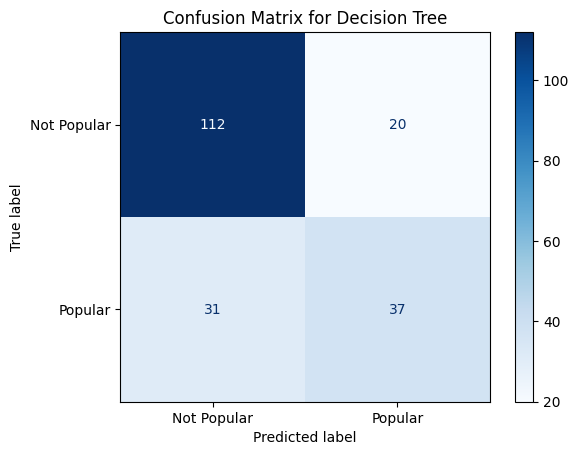

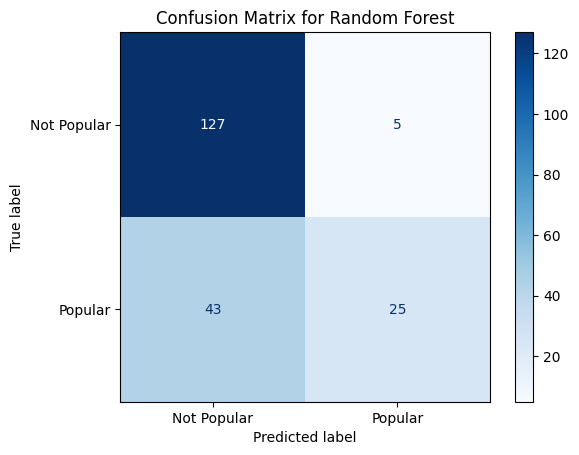

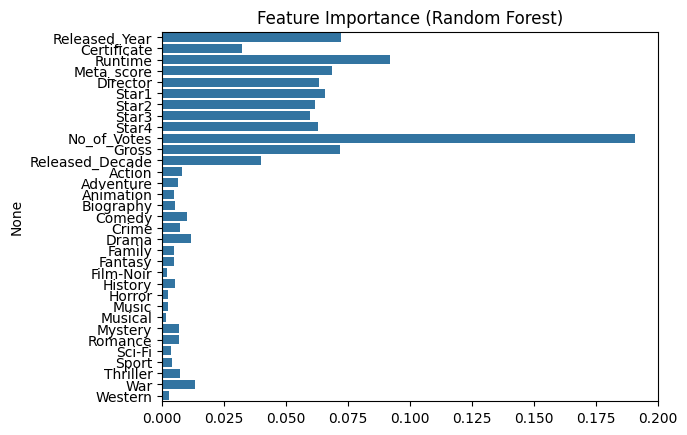

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

label_encoder = LabelEncoder()
for col in ['Director', 'Star1', 'Star2', 'Star3', 'Star4']:
    data[col] = label_encoder.fit_transform(data[col].astype(str))

X = data.drop(['IMDB_Rating', 'is_popular'], axis=1)
y = data['is_popular']

X = X.drop(['Series_Title', 'Genre'], axis=1)
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LogisticRegression(max_iter=1000).fit(X_train, y_train)
dt = DecisionTreeClassifier(random_state=42).fit(X_train, y_train)
rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)

for model, name in zip([lr, dt, rf], ['Logistic Regression', 'Decision Tree', 'Random Forest']):
    y_pred = model.predict(X_test)
    print(f"{name} - Accuracy: {accuracy_score(y_test, y_pred):.2f}, F1 Score: {f1_score(y_test, y_pred):.2f}")
    print(classification_report(y_test, y_pred))

for model, name in zip([lr, dt, rf], ['Logistic Regression', 'Decision Tree', 'Random Forest']):
    disp = ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, display_labels=['Not Popular', 'Popular'], cmap=plt.cm.Blues)
    disp.ax_.set_title(f"Confusion Matrix for {name}")
    plt.show()

feature_importances = rf.feature_importances_
features = X.columns
sns.barplot(x=feature_importances, y=features)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [ ]:
import pandas as pd
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

data = pd.read_csv("IMDB Dataset.csv")

def preprocess_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

data['cleaned_review'] = data['review'].apply(preprocess_text)

label_encoder = LabelEncoder()
data['sentiment'] = label_encoder.fit_transform(data['sentiment'])

X = data['cleaned_review']
y = data['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": LinearSVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

Naive Bayes Accuracy: 0.8489
              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4961
           1       0.85      0.85      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000

Logistic Regression Accuracy: 0.8933
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

SVM Accuracy: 0.8859
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [04:39:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.8622
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4961
           1       0.85      0.88      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



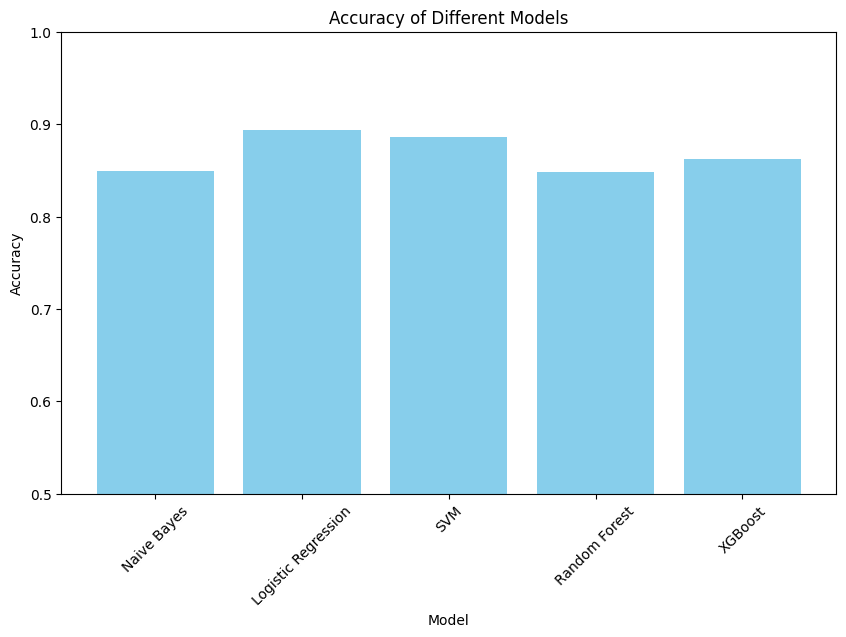

In [ ]:
import matplotlib.pyplot as plt

accuracies = []
for name, model in models.items():
    y_pred = model.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append({"Model": name, "Accuracy": acc})

results_df = pd.DataFrame(accuracies)

plt.figure(figsize=(10, 6))
plt.bar(results_df["Model"], results_df["Accuracy"], color='skyblue')
plt.title("Accuracy of Different Models")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45)
plt.show()

<ipython-input-32-241ed9ed2359>:44: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  matched_reviews['sentiment'] = label_encoder.fit_transform(matched_reviews['sentiment'])


Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4883
           1       0.88      0.89      0.89      4752

    accuracy                           0.89      9635
   macro avg       0.89      0.89      0.89      9635
weighted avg       0.89      0.89      0.89      9635



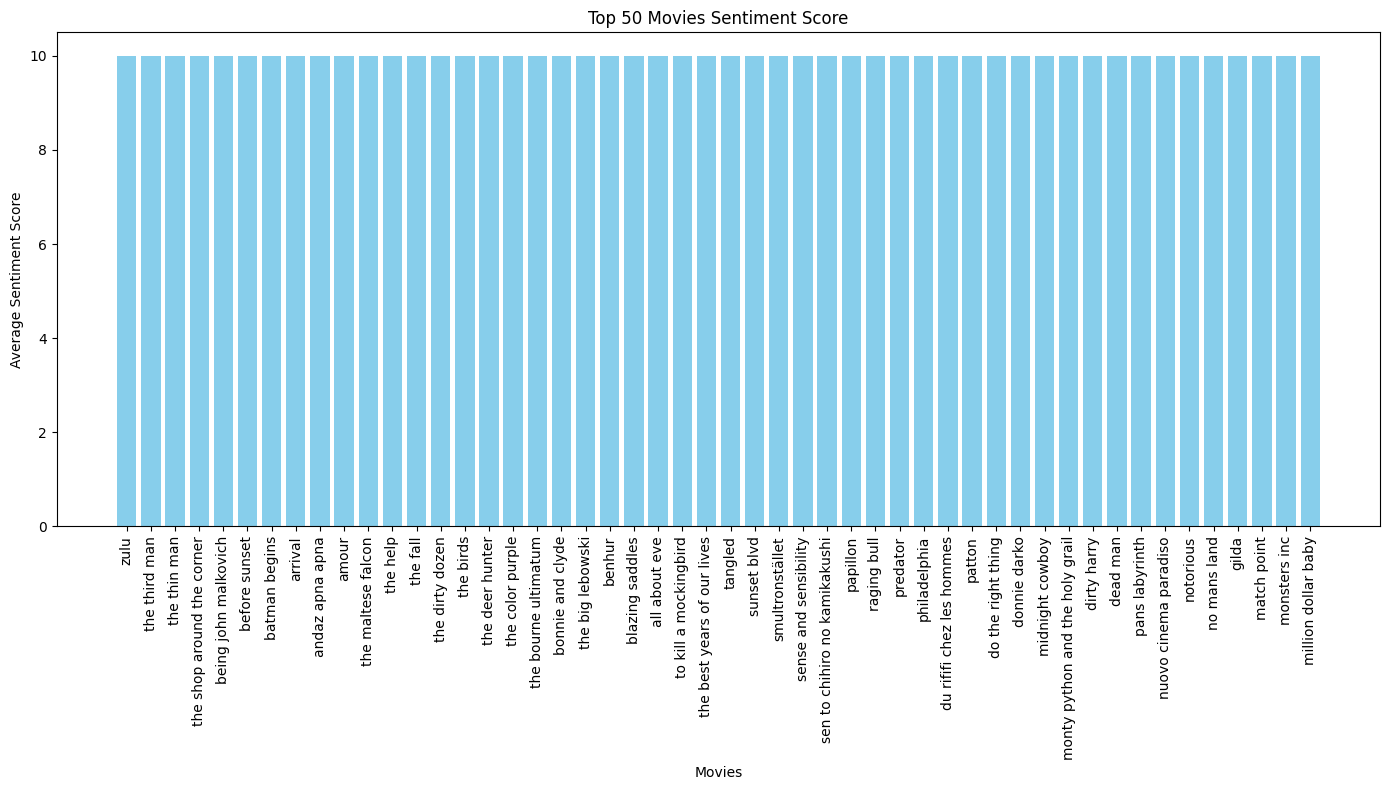

In [ ]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

movies_df = pd.read_csv("imdb_top_1000.csv")
reviews_df = pd.read_csv("IMDB Dataset.csv")

def clean_title(title):
    title = re.sub(r'[^\w\s]', '', title)
    title = title.lower()
    return title

movies_df['clean_title'] = movies_df['Series_Title'].apply(clean_title)

def find_movie_reviews(review, movie_titles):
    for title in movie_titles:
        if title in review:
            return title
    return None

reviews_df['cleaned_review'] = reviews_df['review'].apply(lambda x: re.sub(r'[^\w\s]', '', x.lower()))
movie_titles = movies_df['clean_title'].tolist()
reviews_df['matched_movie'] = reviews_df['cleaned_review'].apply(lambda x: find_movie_reviews(x, movie_titles))

matched_reviews = reviews_df[reviews_df['matched_movie'].notnull()]

label_encoder = LabelEncoder()
matched_reviews['sentiment'] = label_encoder.fit_transform(matched_reviews['sentiment'])

tfidf = TfidfVectorizer(max_features=5000)
X = tfidf.fit_transform(matched_reviews['cleaned_review'])
y = matched_reviews['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

movie_sentiment_counts = matched_reviews.groupby('matched_movie')['sentiment'].value_counts().unstack(fill_value=0)
movie_sentiment_counts['total'] = movie_sentiment_counts.sum(axis=1)
movie_sentiment_counts['score'] = (
    movie_sentiment_counts[1] * 10 + movie_sentiment_counts[0] * 1
) / movie_sentiment_counts['total']

top_50_movies = movie_sentiment_counts.sort_values('score', ascending=False).head(50)

plt.figure(figsize=(14, 8))
plt.bar(top_50_movies.index, top_50_movies['score'], color='skyblue')
plt.title("Top 50 Movies Sentiment Score")
plt.ylabel("Average Sentiment Score")
plt.xlabel("Movies")
plt.xticks(rotation=90, fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
print(matched_reviews['sentiment'].value_counts())

sentiment
0    24117
1    24055
Name: count, dtype: int64


In [ ]:
print(f"总评论数量: {len(reviews_df)}")
print(f"匹配到的评论数量: {len(matched_reviews)}")

总评论数量: 50000
匹配到的评论数量: 48172


In [ ]:
print("匹配到的评论情感分布：")
print(matched_reviews['sentiment'].value_counts())

匹配到的评论情感分布：
sentiment
0    24117
1    24055
Name: count, dtype: int64


过滤后电影数量: 111
sentiment             total     score
matched_movie                        
12 angry men             13  6.769231
1917                     10  8.600000
2001 a space odyssey     26  8.384615
a clockwork orange       16  5.625000
adaptation               19  6.684211
前 20 部电影的分数：
sentiment                       total     score
matched_movie                                  
the game                           16  8.687500
singin in the rain                 26  8.653846
1917                               10  8.600000
vertigo                            29  8.551724
one flew over the cuckoos nest     23  8.478261
2001 a space odyssey               26  8.384615
blade runner                       13  8.384615
metropolis                         42  8.333333
braveheart                         29  8.310345
double indemnity                   16  8.250000
spotlight                          12  8.250000
memento                            32  8.250000
its a wonderful life               5

<ipython-input-43-b6e569099ea6>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_movie_sentiment_counts['score'] = (


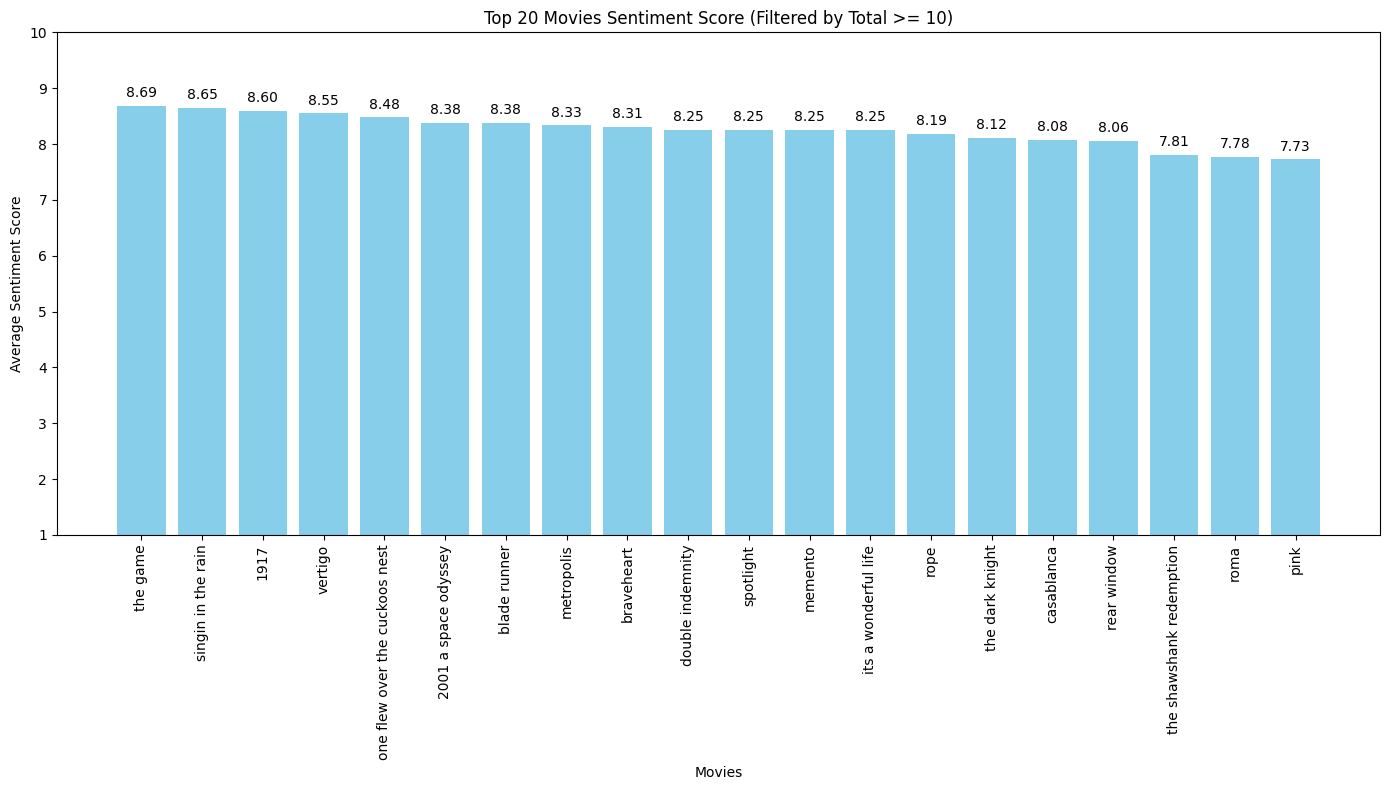

In [ ]:
filtered_movie_sentiment_counts = movie_sentiment_counts[movie_sentiment_counts['total'] >= 10]

print(f"Filtered movie count: {len(filtered_movie_sentiment_counts)}")

negative_weight = 3
positive_weight = 10

filtered_movie_sentiment_counts['score'] = (
    (filtered_movie_sentiment_counts[1] * positive_weight + filtered_movie_sentiment_counts[0] * negative_weight)
) / filtered_movie_sentiment_counts['total']

print(filtered_movie_sentiment_counts[['total', 'score']].head())

top_20_movies = filtered_movie_sentiment_counts.sort_values('score', ascending=False).head(20)

print("Top 20 movies by score:")
print(top_20_movies[['total', 'score']])

plt.figure(figsize=(14, 8))
bars = plt.bar(top_20_movies.index, top_20_movies['score'], color='skyblue')

plt.title("Top 20 Movies Sentiment Score (Filtered by Total >= 10)")
plt.ylabel("Average Sentiment Score")
plt.xlabel("Movies")
plt.ylim(1, 10)
plt.xticks(rotation=90, fontsize=10)

for bar, score in zip(bars, top_20_movies['score']):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.1,
        f"{score:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='black'
    )

plt.tight_layout()
plt.show()

<ipython-input-44-2d2bc180e88d>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_movie_sentiment_counts['score'] = (


前 20 部电影的情感分数和 IMDb 评分对比：
                     matched_movie     score  IMDB_Rating
0                         the game  8.687500          7.8
1               singin in the rain  8.653846          8.3
2                             1917  8.600000          8.3
3                          vertigo  8.551724          8.3
4   one flew over the cuckoos nest  8.478261          8.7
5             2001 a space odyssey  8.384615          8.3
6                     blade runner  8.384615          8.1
7                       metropolis  8.333333          8.3
8                       braveheart  8.310345          8.3
9                 double indemnity  8.250000          8.3
10                       spotlight  8.250000          8.1
11                         memento  8.250000          8.4
12            its a wonderful life  8.250000          8.6
13                            rope  8.185185          8.0
14                 the dark knight  8.115385          9.0
15                      casablanca  8.080645  

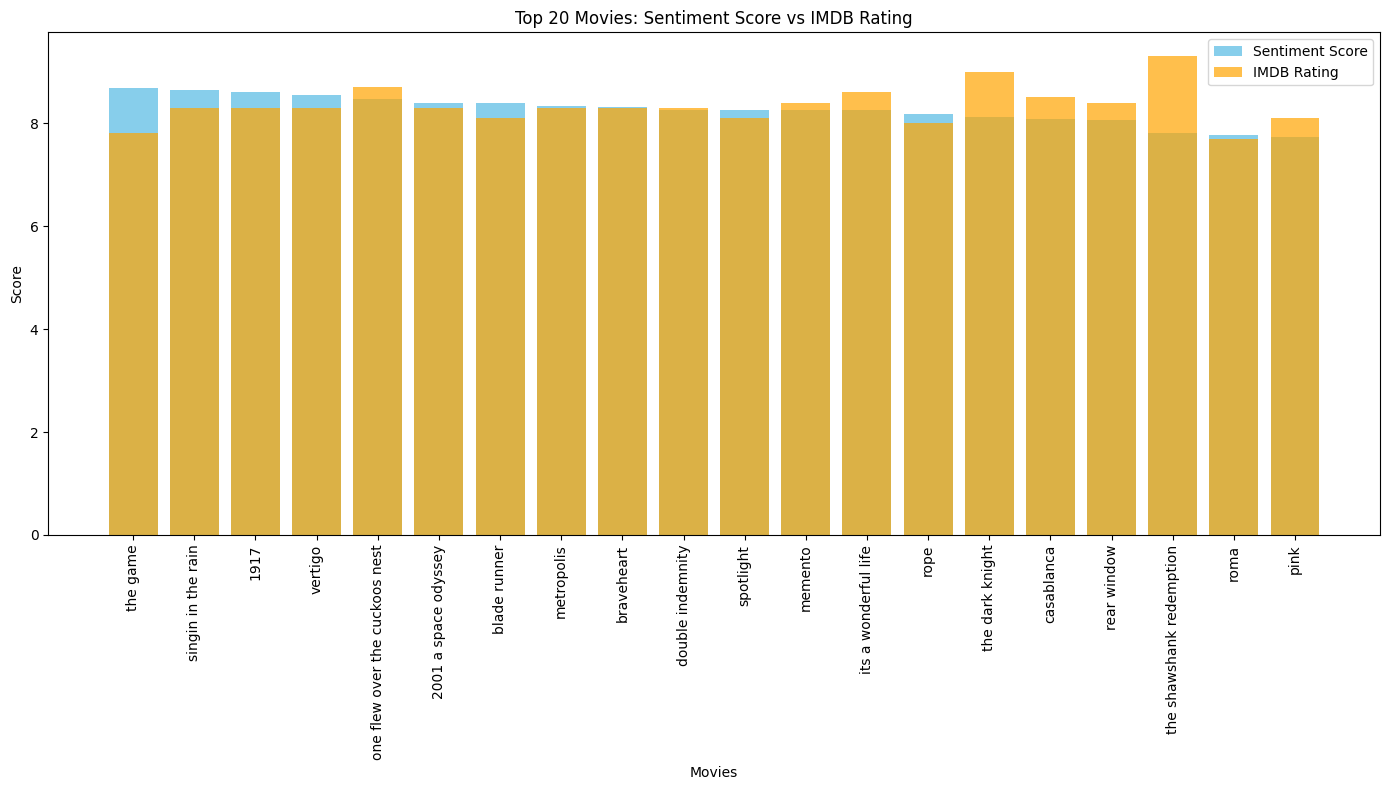

In [ ]:
filtered_movie_sentiment_counts = movie_sentiment_counts[movie_sentiment_counts['total'] >= 10]

negative_weight = 3
positive_weight = 10

filtered_movie_sentiment_counts['score'] = (
    (filtered_movie_sentiment_counts[1] * positive_weight + filtered_movie_sentiment_counts[0] * negative_weight)
) / filtered_movie_sentiment_counts['total']

top_20_movies = filtered_movie_sentiment_counts.sort_values('score', ascending=False).head(20)
top_20_movies = top_20_movies.reset_index()

comparison = pd.merge(
    top_20_movies,
    movies_df[['clean_title', 'IMDB_Rating']],
    left_on='matched_movie',
    right_on='clean_title',
    how='left'
)

print("Top 20 Movies Sentiment Score vs IMDB Rating:")
print(comparison[['matched_movie', 'score', 'IMDB_Rating']])

plt.figure(figsize=(14, 8))
x = comparison['matched_movie']
plt.bar(x, comparison['score'], color='skyblue', label='Sentiment Score')
plt.bar(x, comparison['IMDB_Rating'], color='orange', alpha=0.7, label='IMDB Rating')
plt.title("Top 20 Movies: Sentiment Score vs IMDB Rating")
plt.ylabel("Score")
plt.xlabel("Movies")
plt.xticks(rotation=90, fontsize=10)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import requests
import base64
import pandas as pd
import time
import os
import json

CLIENT_ID = "dd60fa3012b74e14bf28bce0259f55b9"
CLIENT_SECRET = "651526bd2bc3456ea5dff233d15c852e"

def get_spotify_token(client_id, client_secret):
    url = "https://accounts.spotify.com/api/token"
    headers = {
        "Authorization": "Basic " + base64.b64encode(f"{client_id}:{client_secret}".encode()).decode()
    }
    data = {"grant_type": "client_credentials"}
    response = requests.post(url, headers=headers, data=data)

    if response.status_code == 200:
        return response.json().get("access_token")
    else:
        raise Exception("Failed to get Spotify token: " + response.text)

def search_spotify(query, token, search_type="track", limit=10):
    url = f"https://api.spotify.com/v1/search?q={query}&type={search_type}&limit={limit}"
    headers = {"Authorization": f"Bearer {token}"}
    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        return response.json()
    elif response.status_code == 429:
        retry_after = int(response.headers.get("Retry-After", 5))
        time.sleep(retry_after)
        return search_spotify(query, token, search_type, limit)
    else:
        raise Exception("Failed to search Spotify: " + response.text)

def get_audio_features(track_id, token):
    url = f"https://api.spotify.com/v1/audio-features/{track_id}"
    headers = {"Authorization": f"Bearer {token}"}
    response = requests.get(url, headers=headers)

    if response.status_code == 200:
        return response.json()
    else:
        return None

CACHE_DIR = "spotify_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def search_spotify_with_cache(query, token, search_type="track", limit=10):
    cache_file = os.path.join(CACHE_DIR, f"{query.replace(' ', '_')}.json")
    if os.path.exists(cache_file):
        with open(cache_file, "r") as f:
            return json.load(f)

    result = search_spotify(query, token, search_type, limit)

    with open(cache_file, "w") as f:
        json.dump(result, f)

    return result

def find_movie_songs(movie_titles, token):
    song_data = []

    for movie in movie_titles:
        result = search_spotify_with_cache(movie, token, search_type="track", limit=10)

        for track in result['tracks']['items']:
            track_id = track['id']
            audio_features = get_audio_features(track_id, token)

            song_data.append({
                "movie": movie,
                "song_name": track['name'],
                "artist": ", ".join([artist['name'] for artist in track['artists']]),
                "album": track['album']['name'],
                "release_date": track['album']['release_date'],
                "popularity": track['popularity'],
                "duration_ms": track['duration_ms'],
                "danceability": audio_features.get('danceability') if audio_features else None,
                "energy": audio_features.get('energy') if audio_features else None,
                "valence": audio_features.get('valence') if audio_features else None,
                "tempo": audio_features.get('tempo') if audio_features else None,
            })

    return pd.DataFrame(song_data)

if __name__ == "__main__":
    spotify_token = get_spotify_token(CLIENT_ID, CLIENT_SECRET)
    imdb_data = pd.read_csv("imdb_top_1000.csv")
    top_100_movies = imdb_data.head(100)
    movie_titles = top_100_movies['Series_Title'].tolist()
    movie_songs_df = find_movie_songs(movie_titles, spotify_token)
    print(movie_songs_df)
    movie_songs_df.to_csv("top_100_movie_songs_data.csv", index=False)
    print("Top 100 movie songs data saved to 'top_100_movie_songs_data.csv'")

Searching for songs related to: The Shawshank Redemption
Searching for songs related to: The Godfather
Searching for songs related to: The Dark Knight
Searching for songs related to: The Godfather: Part II
Searching for songs related to: 12 Angry Men
Searching for songs related to: The Lord of the Rings: The Return of the King
Searching for songs related to: Pulp Fiction
Searching for songs related to: Schindler's List
Searching for songs related to: Inception
Searching for songs related to: Fight Club
Searching for songs related to: The Lord of the Rings: The Fellowship of the Ring
Searching for songs related to: Forrest Gump
Rate limit exceeded. Retrying after 2 seconds...
Rate limit exceeded. Retrying after 1 seconds...
Searching for songs related to: Il buono, il brutto, il cattivo
Searching for songs related to: The Lord of the Rings: The Two Towers
Searching for songs related to: The Matrix
Searching for songs related to: Goodfellas
Searching for songs related to: Star Wars: Epis

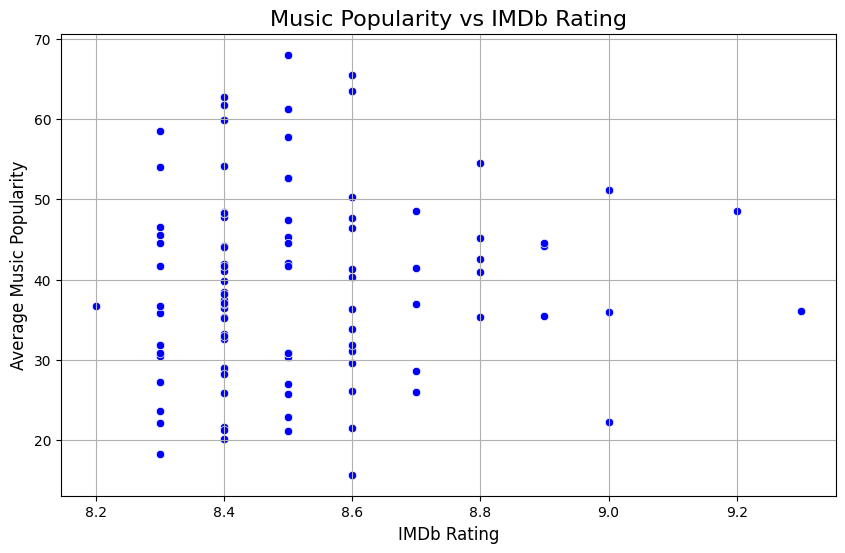

Correlation between IMDb Rating and Music Popularity: 0.06


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_popularity_vs_imdb(movie_songs_df, imdb_data):
    avg_popularity = movie_songs_df.groupby("movie")["popularity"].mean().reset_index()
    avg_popularity.columns = ["movie", "avg_popularity"]

    merged = pd.merge(imdb_data[["Series_Title", "IMDB_Rating"]], avg_popularity,
                      left_on="Series_Title", right_on="movie", how="inner")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=merged, x="IMDB_Rating", y="avg_popularity", color="blue")
    plt.title("Music Popularity vs IMDb Rating", fontsize=16)
    plt.xlabel("IMDb Rating", fontsize=12)
    plt.ylabel("Average Music Popularity", fontsize=12)
    plt.grid(True)
    plt.show()

    corr = merged["IMDB_Rating"].corr(merged["avg_popularity"])
    print(f"Correlation between IMDb Rating and Music Popularity: {corr:.2f}")

analyze_popularity_vs_imdb(movie_songs_df, imdb_data)

<ipython-input-49-ee419fa87a2a>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_artists, x="artist", y="num_songs", palette="viridis")


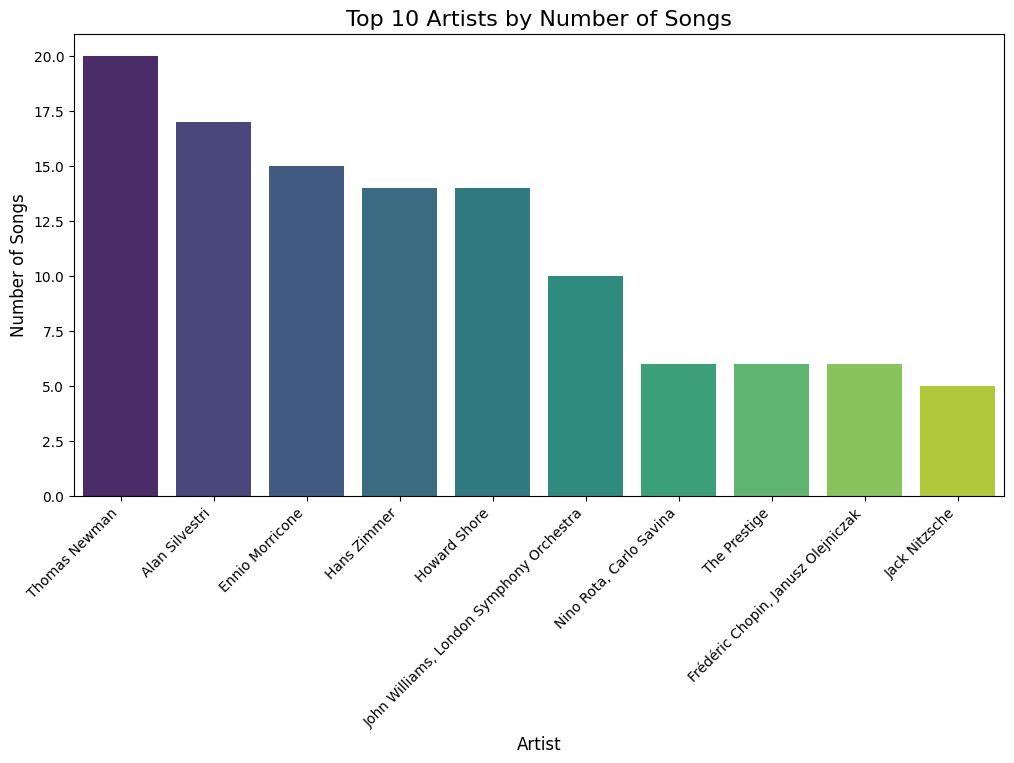

<ipython-input-49-ee419fa87a2a>:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_artists, x="artist", y="avg_popularity", palette="coolwarm")


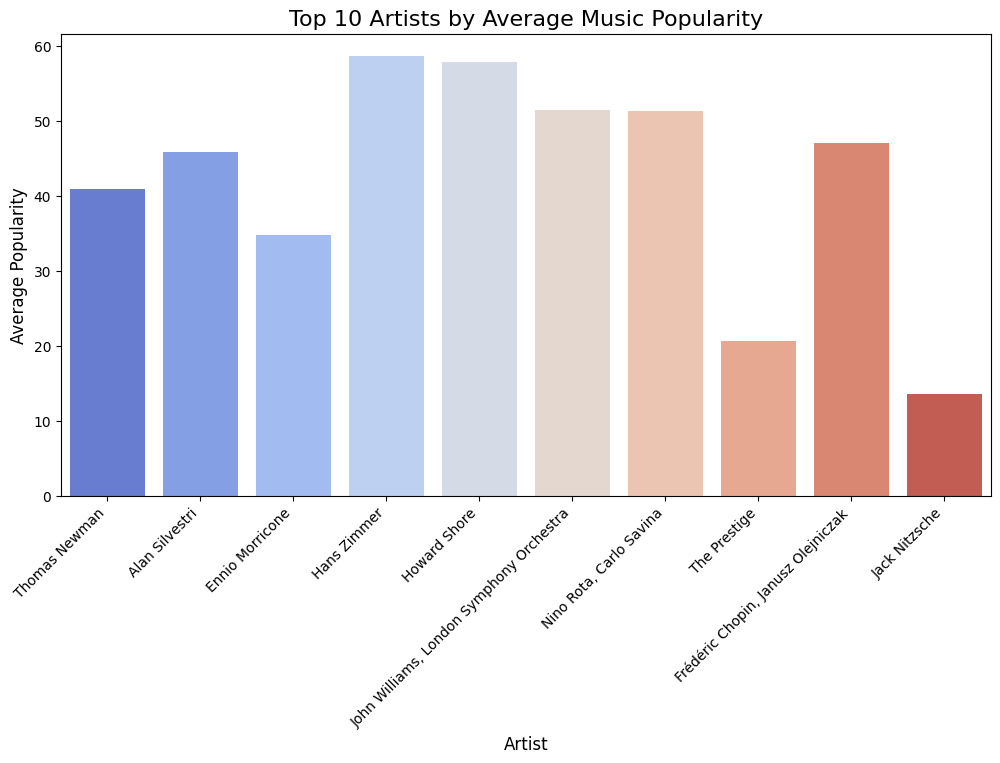

In [ ]:
def analyze_artist_contributions(movie_songs_df):
    artist_stats = movie_songs_df.groupby("artist").agg(
        num_songs=("song_name", "count"),
        avg_popularity=("popularity", "mean")
    ).reset_index()

    top_artists = artist_stats.sort_values("num_songs", ascending=False).head(10)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_artists, x="artist", y="num_songs", palette="viridis")
    plt.title("Top 10 Artists by Number of Songs", fontsize=16)
    plt.xlabel("Artist", fontsize=12)
    plt.ylabel("Number of Songs", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_artists, x="artist", y="avg_popularity", palette="coolwarm")
    plt.title("Top 10 Artists by Average Music Popularity", fontsize=16)
    plt.xlabel("Artist", fontsize=12)
    plt.ylabel("Average Popularity", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.show()

analyze_artist_contributions(movie_songs_df)

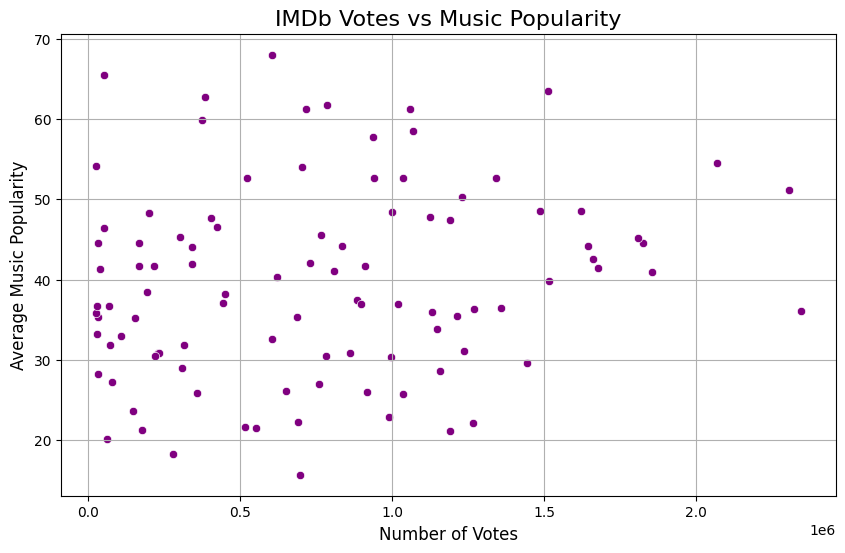

Correlation between Number of Votes and Music Popularity: 0.17


In [ ]:
def analyze_votes_vs_popularity(movie_songs_df, imdb_data):
    avg_popularity = movie_songs_df.groupby("movie")["popularity"].mean().reset_index()
    avg_popularity.columns = ["movie", "avg_popularity"]

    merged = pd.merge(imdb_data[["Series_Title", "No_of_Votes"]], avg_popularity,
                      left_on="Series_Title", right_on="movie", how="inner")

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=merged, x="No_of_Votes", y="avg_popularity", color="purple")
    plt.title("IMDb Votes vs Music Popularity", fontsize=16)
    plt.xlabel("Number of Votes", fontsize=12)
    plt.ylabel("Average Music Popularity", fontsize=12)
    plt.grid(True)
    plt.show()

    corr = merged["No_of_Votes"].corr(merged["avg_popularity"])
    print(f"Correlation between Number of Votes and Music Popularity: {corr:.2f}")

analyze_votes_vs_popularity(movie_songs_df, imdb_data)